In [2]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings # to counter warnings
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [3]:
#create database connection
conn = sqlite3.connect('inventory.db')

#fetching data from database 
df = pd.read_sql_query('select * from vendor_sales_summary',conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesprice,TotalSalesDollars,TotalSalesQuantity,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,stockturnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,672819.31,5101919.51,142049.0,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,561512.37,4819073.49,160247.0,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,461140.15,4538120.60,187140.0,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,420050.01,4475972.88,200412.0,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,545778.28,4223107.62,135838.0,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis
- Previously, we examined the various tables in the database to identify key variables, understand their relationships , and determine which ones should be included in the final analysis.

- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data  quality before quality before proceeding with further analysis

In [ ]:
# summary statistics
df.describe().T #T = tranpose


,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesprice,10692.0,18793.783627,44952.773386,0.000000,289.710000,2857.800000,16059.562500,6.728193e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.000000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05


In [ ]:
# finding no of  (-inf and inf) 
df['ProfitMargin'].isin([np.inf, -np.inf]).sum()

np.int64(0)

In [ ]:
# treating -inf and inf
df['ProfitMargin'] = (df['ProfitMargin'].replace([np.inf, -np.inf], np.nan))

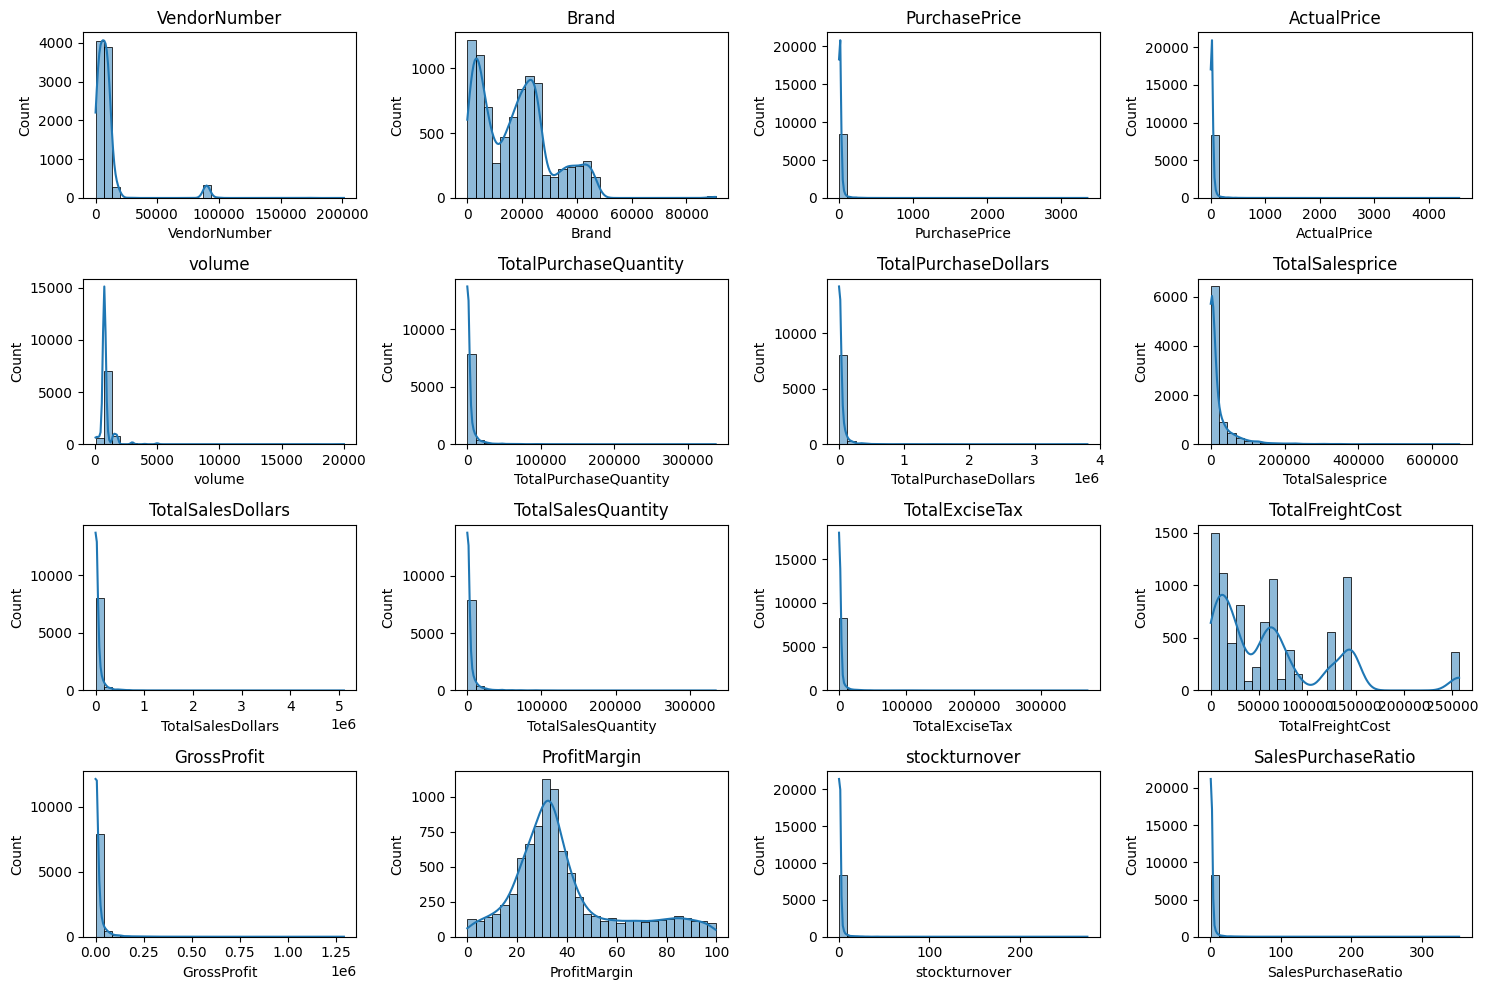

In [23]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize = (15, 10))
for i ,col in  enumerate(numerical_cols):
    plt.subplot(4,4, i+1) # ajust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

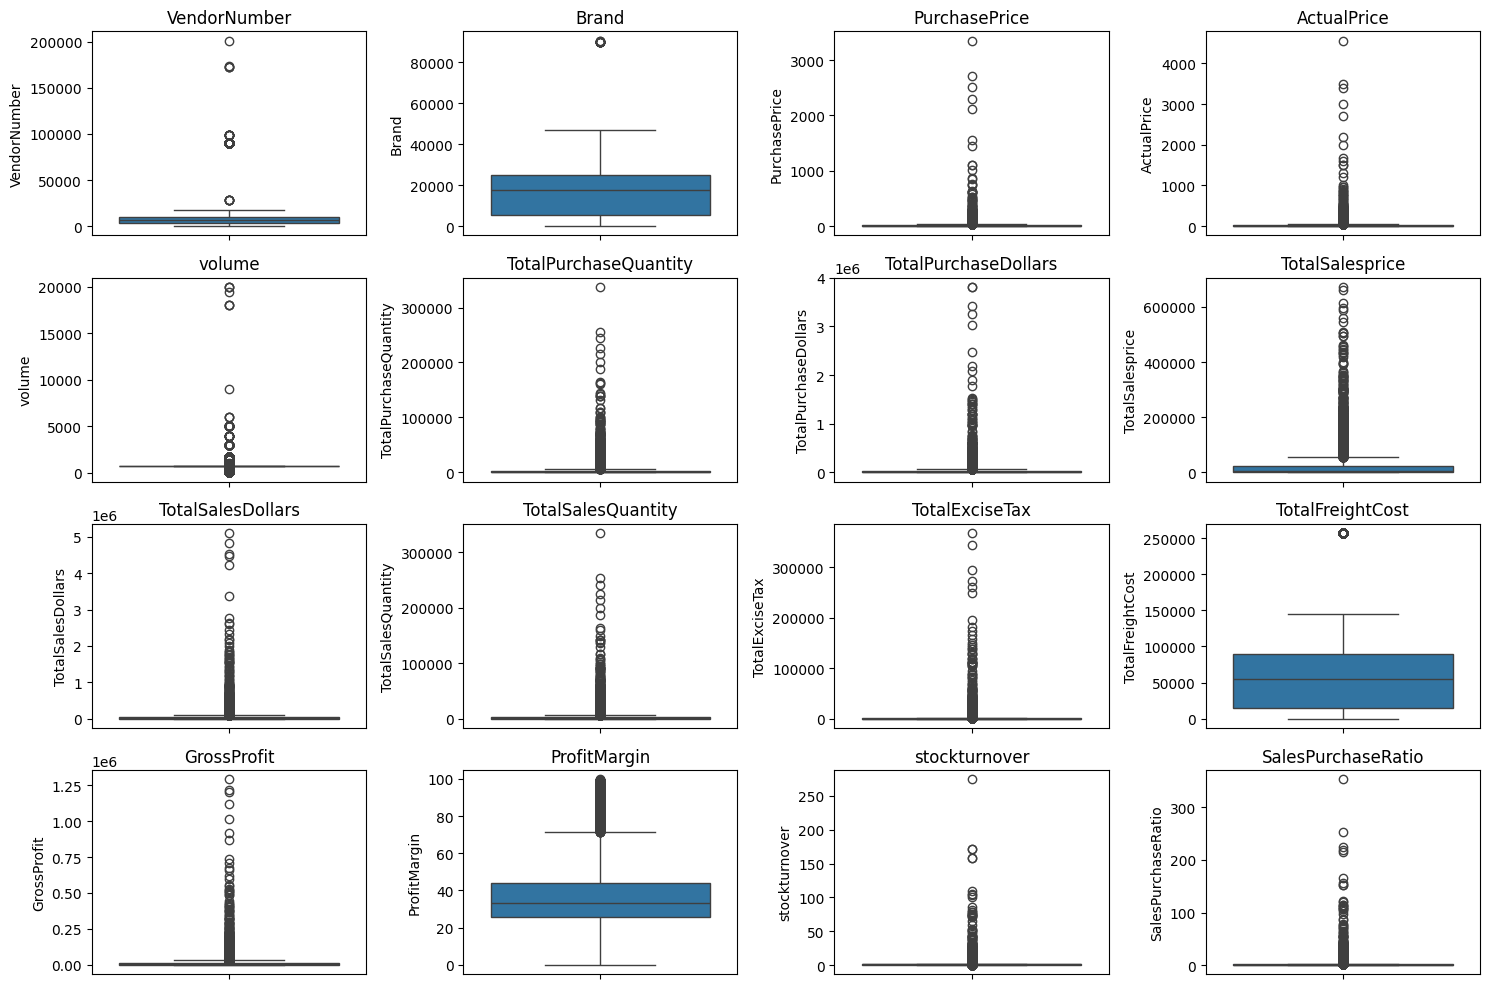

In [22]:
# Outlier detection with boxplot
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insights:

 Negative & Zero values:
- Gross Profit: Minimum value is -52,002.78, indicating losses.Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than purchase price.
-Profit Margin: has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
- total sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

Outliers indicated by High Standard Deviations :
- Purchases & Actual Prices = The max values(5,681.81 & 7499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
- Freight Cost: Huge variation from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while other remain in stock indefinitely. Value more than 1 indicate that Sold quantity for that products is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [20]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesprice', 'TotalSalesDollars',
       'TotalSalesQuantity', 'TotalExciseTax', 'TotalFreightCost',
       'GrossProfit', 'ProfitMargin', 'stockturnover', 'SalesPurchaseRatio'],
      dtype='object')

In [21]:
# filtering data by removing inconsistencies
df = pd.read_sql_query("""Select * from vendor_sales_summary where ProfitMargin > 0 And GrossProfit >0 And TotalSalesQuantity > 0""",conn)


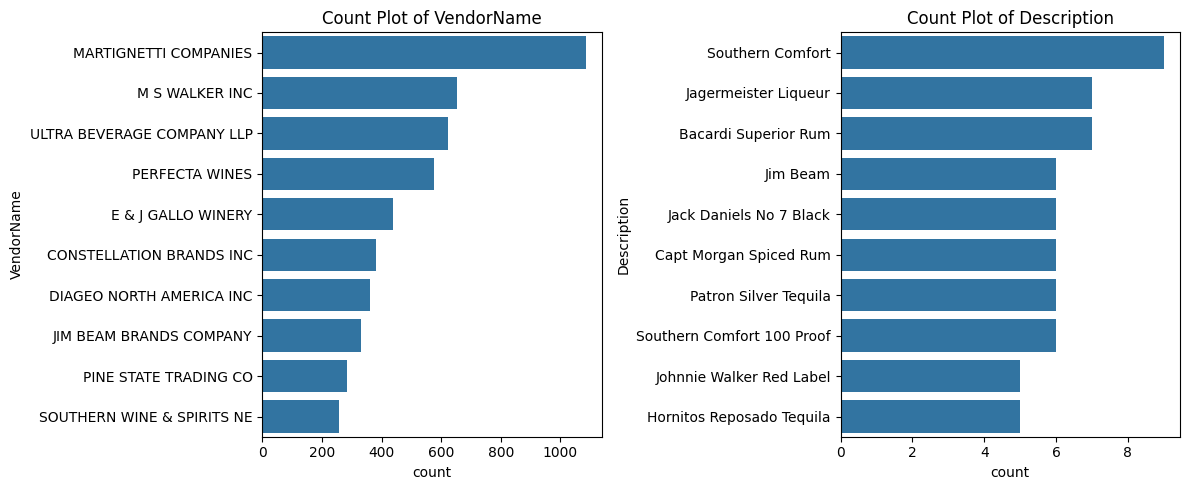

In [25]:
# Counts Plots for categorical columns
categorical_cols = ["VendorName","Description"]
plt.figure(figsize=(12, 5))
for i , col in enumerate(categorical_cols):
    plt.subplot(1 , 2, i+1)
    sns.countplot(y =df[col], order=df[col].value_counts().index[:10]) #Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

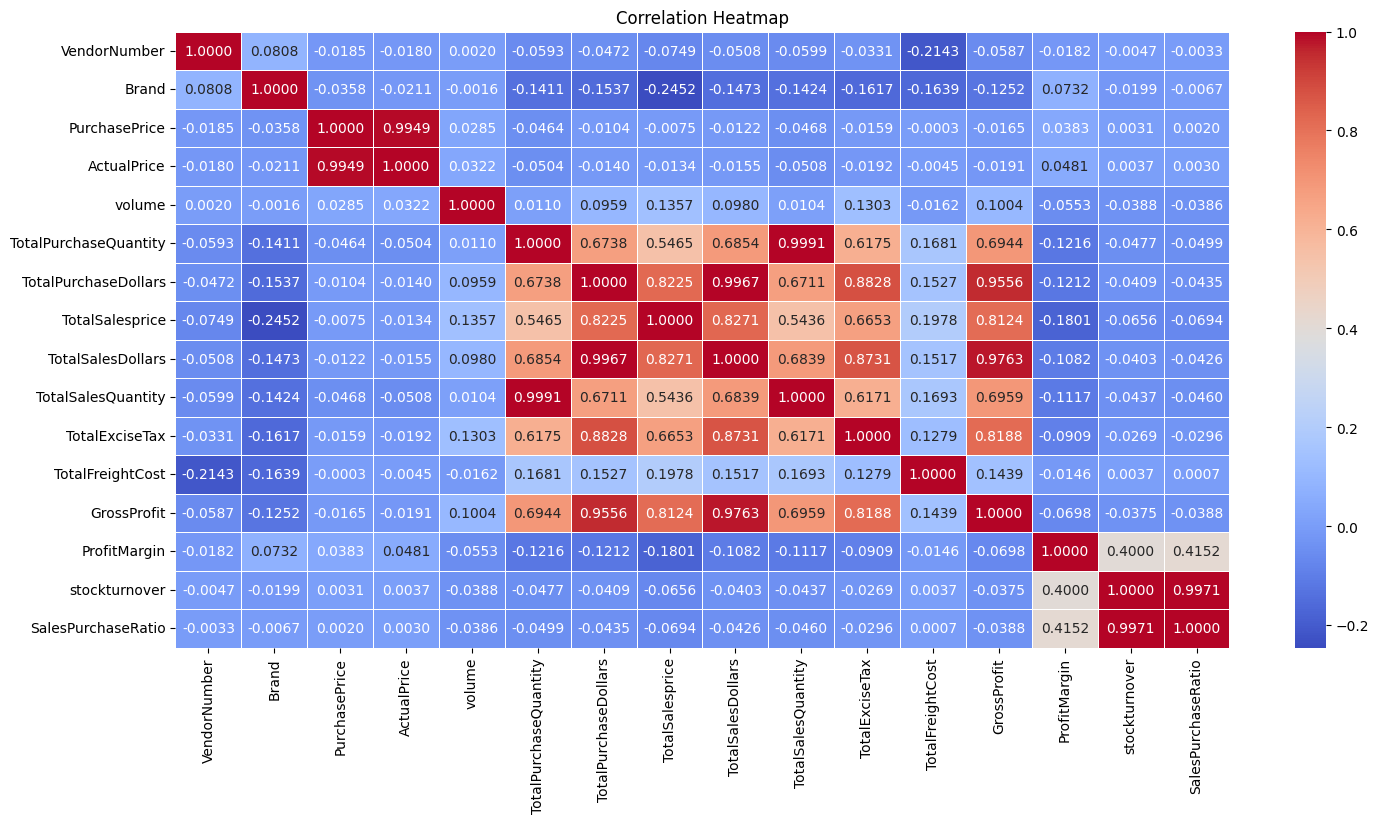

In [ ]:
# Heatmap for correlation
plt.figure(figsize = (17 , 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True , fmt=".4f", cmap="coolwarm" , linewidths = 0.5)
#annot give values , fmt is formating till how many decimal points
plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights
- PurchasePrice has weak correlations with ToalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
- strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
- Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
- StockTurnover has weak negative correlations with both GrossProfit (-0.038) and Profit Margin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

# Data Analysis

Identify Brands that needs promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins

In [32]:
brand_performance = df.groupby('Description').agg({'TotalSalesDollars':'sum',
                               'ProfitMargin':'mean'}).reset_index()

In [33]:
low_sales_threshold = brand_performance ['TotalSalesDollars'].quantile(0.15)
high_sales_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [35]:
target_brands = brand_performance[(brand_performance['TotalSalesDollars'] <= low_sales_threshold) & (brand_performance['ProfitMargin'] >= high_sales_threshold)]
print("Brands with low Sales  but High Profit Margins")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low Sales  but High Profit Margins


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748
